# GMP AI 실습 — 전체 커리큘럼 (10개 예제)

## 5개 학습 모듈

| 모듈 | # | 주제 | 난이도 | GMP 핵심 규정 | AI 기법 |
|:----:|:--:|------|:------:|-------------|--------|
| **① 기초·탐색** | 1 | 품질 데이터 탐색 (EDA) | ⭐ | ICH Q8 QbD · CQA/CPP 파악 | EDA · 상관분석 · 시각화 |
| | 2 | SPC 관리도 | ⭐⭐ | ICH Q10 PQS · PAT 연속 모니터링 | Shewhart · CUSUM · EWMA |
| **② 예측적 품질관리** | 3 | OOS 발생 예측 | ⭐⭐⭐ | 21 CFR 211.192 OOS 조사 | Random Forest 분류 |
| | 4 | 공정 이상 탐지 | ⭐⭐⭐ | ICH Q9 품질 리스크 관리 | Isolation Forest |
| **③ QMS 자동화** | 5 | Deviation 자동 분류 | ⭐⭐⭐⭐ | ICH Q10 CAPA · GDP | K-Means 클러스터링 |
| | 6 | CAPA 효과성 예측 | ⭐⭐⭐⭐ | 21 CFR 820.100 · ICH Q10 | Gradient Boosting |
| **④ 공정 모니터링** | 7 | 시계열 공정 상태 패턴 인식 | ⭐⭐⭐⭐ | FDA PAT · GMP Annex 11 | Conv1D CNN |
| | 8 | 설비 예지보수 (PdM) | ⭐⭐⭐⭐⭐ | EU GMP Annex 1 · GAMP 5 | LSTM · RUL 회귀 |
| **⑤ 케이스 스터디** | 9 | 페니실린 공정데이터탐색 (실제 데이터) | ⭐⭐⭐ | ICH Q8 CPP/CQA · ALCOA+ | EDA · 다변량 분석 |
| | 10 | 페니실린 소프트센서·RTRT (실제 데이터) | ⭐⭐⭐⭐⭐ | PAT 소프트센서 · RTRT | RF · 시계열 예측 |

> 💡 **학습 흐름**: 모듈①(데이터 기초) → ②(예측 모델) → ③(QMS 자동화) → ④(시계열·딥러닝) → ⑤(실데이터 종합)  
> 예제 9·10은 동일한 IndPenSim 실제 발효 데이터를 사용하는 **케이스 스터디 쌍**입니다.

## ⚙️ 공통 환경 설정 (가장 먼저 실행하세요!)

In [2]:
# =====================================================
# 공통 설정: 모든 예제에서 사용하는 라이브러리 한 번에 설치/로드
# =====================================================

# ── Colab 한글 폰트 설치 ──
!apt-get install -y fonts-nanum -q 2>/dev/null

import matplotlib
import matplotlib.font_manager as fm
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
matplotlib.rcParams['font.family'] = 'NanumGothic'
matplotlib.rcParams['axes.unicode_minus'] = False

%config InlineBackend.figure_format = 'retina'

# ── 필요한 라이브러리 불러오기 ──
import numpy as np              # 수치 계산
import pandas as pd             # 데이터 표(DataFrame) 처리
import matplotlib.pyplot as plt # 그래프 그리기
import seaborn as sns           # 고급 통계 그래프
import warnings
warnings.filterwarnings('ignore')


print("✅ 환경 설정 완료! 이제 예제 1부터 순서대로 실행하세요.")
print(f"   NumPy  버전: {np.__version__}")
print(f"   Pandas 버전: {pd.__version__}")


Reading package lists...
Building dependency tree...
Reading state information...
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 2 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 0s (61.6 MB/s)
Selecting previously unselected package fonts-nanum.
(Reading database ... 118242 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
✅ 환경 설정 완료! 이제 예제 1부터 순서대로 실행하세요.
   NumPy  버전: 2.0.2
   Pandas 버전: 2.2.2


---
## 예제 1: GMP 품질 데이터 탐색 및 시각화 ⭐ 초급

### 🏭 배경 설명

제약 공장에서 정제(Tablet)를 생산할 때는 매 배치(Batch)마다 다양한 품질 검사를 수행합니다.
GMP(의약품 제조 품질 관리 기준)에 따라 수집된 품질 데이터를 분석하면, 어떤 배치가 기준을
만족하는지, 어떤 공정 파라미터가 품질에 영향을 미치는지 파악할 수 있습니다.

**이 예제에서 배우는 것:**
- Python으로 데이터를 표(DataFrame) 형태로 만들고 살펴보는 방법
- 평균, 표준편차 등 기본 통계 계산
- 히스토그램·박스플롯·산점도로 품질 데이터 시각화
- OOS(Out of Specification, 규격 초과) 배치 자동 식별

**가상 시나리오:** 항고혈압제 정제 200배치의 함량균일성, 경도, 붕해시간 데이터를 분석합니다.


---
## 📍 모듈 ① — 기초·탐색 | 예제 1: GMP 품질 데이터 탐색 (EDA)

### 🏛️ GMP 커버리지
| 규정 / 가이드라인 | 이 예제에서의 적용 |
|----------------|-----------------|
| **ICH Q8(R2) QbD** | QTPP → CQA → CPP 연결 관계를 데이터로 확인 |
| **ICH Q9 품질 리스크 관리** | 상관관계 히트맵 = Risk Ranking & Filtering의 데이터 기반 버전 |
| **21 CFR 211 제조·관리** | 배치 기록의 통계 요약 → 이상값·OOT 패턴 사전 파악 |

### 🤖 AI 도입 장점
| 전통 방법 | AI / 데이터 과학 방법 | 개선 효과 |
|---------|-------------------|---------|
| 소수 변수를 개별 Excel 차트로 검토 | 수십 개 변수를 한번에 상관·분포 시각화 | 분석 시간 90% 단축 |
| 전문가 직관에 의존한 CPP 선정 | 상관계수·Feature Importance로 CPP 정량화 | 주관 오류 제거 |
| 배치 간 비교가 어려움 | 다변량 산점도·박스플롯으로 배치 군집 파악 | QbD Design Space 설정 근거 |

### 🎯 핵심 Takeaway
> **"AI 모델의 품질은 데이터 이해의 깊이에 달려 있다."**

1. EDA는 AI 프로젝트의 **첫 번째이자 가장 중요한 단계** — 데이터를 모르면 모델을 믿을 수 없다
2. 상관관계 분석은 QbD의 **Risk Assessment** 단계를 데이터로 구현하는 가장 빠른 방법
3. 이상값(Outlier)과 OOT(Out-of-Trend) 패턴은 EDA 단계에서 미리 발견해야 모델 오염을 방지

### ➡️ 다음 예제
**예제 2 (SPC 관리도)**: EDA로 파악한 CPP 변수들을 실시간으로 **통계적 관리**하는 방법 학습

In [3]:
# =====================================================
# 예제 1: GMP 품질 데이터 탐색 및 시각화
# =====================================================

# ─────────────────────────────────────────────────────
# 1-1. 가상의 GMP 품질 데이터 만들기
# (실제 현장에서는 LIMS나 엑셀 파일에서 불러옵니다)
# ─────────────────────────────────────────────────────

np.random.seed(42)   # 난수 고정 → 실행마다 같은 결과 보장

n = 200   # 총 200개 배치 시뮬레이션

# 함량균일성 (%): 정상적으로 평균 100%, 표준편차 2%로 분포
assay = np.random.normal(100, 2.0, n)

# 경도 (N): 평균 80N, 표준편차 8N
hardness = np.random.normal(80, 8, n)

# 붕해시간 (disintegration time, 분): 평균 12분 (음수 방지를 위해 절댓값 사용)
disint = np.abs(np.random.normal(12, 2, n))

# 데이터프레임(표) 생성 ── 딕셔너리(사전) 형태로 작성 후 변환
df = pd.DataFrame({
    'batch_no'   : [f'BT-{2024000+i}' for i in range(1, n+1)],  # 배치 번호
    'assay_pct'  : assay,          # 함량균일성 (%)
    'hardness_N' : hardness,       # 경도 (N)
    'disint_min' : disint,         # 붕해시간 (분)
    'month'      : np.tile(np.arange(1, 13), n//12 + 1)[:n],     # 제조 월
    'line'       : np.random.choice(['라인-A', '라인-B', '라인-C'], n)  # 제조 라인
})

# 의도적으로 10개 배치를 OOS 범위로 만들기 (현실 시뮬레이션)
oos_idx = np.random.choice(n, 10, replace=False)
df.loc[oos_idx, 'assay_pct'] += np.random.choice([-20, 20], 10)

print(f"📊 데이터 생성 완료: 총 {len(df)}개 배치")
print("\n🔍 처음 5행 미리보기:")
df.head()         # .head()는 앞에서 5행만 출력


📊 데이터 생성 완료: 총 200개 배치

🔍 처음 5행 미리보기:


,batch_no,assay_pct,hardness_N,disint_min,month,line
0,BT-2024001,100.993428,82.862299,8.811145,1,라인-C
1,BT-2024002,99.723471,84.486276,10.801250,2,라인-A
2,BT-2024003,101.295377,88.664410,12.010487,3,라인-B
3,BT-2024004,103.046060,88.430416,12.093961,4,라인-C
4,BT-2024005,99.531693,68.978645,11.099869,5,라인-C


In [4]:
# ─────────────────────────────────────────────────────
# 1-2. 기본 통계 분석 및 OOS 판정
# ─────────────────────────────────────────────────────

# describe()로 기본 통계(개수, 평균, 표준편차, 최솟값, 사분위수, 최댓값) 한 번에 계산
print("=" * 55)
print("📈 품질 지표 기술통계량")
print("=" * 55)
stats = df[['assay_pct', 'hardness_N', 'disint_min']].describe()
stats.index   = ['배치수', '평균', '표준편차', '최솟값', '1사분위', '중앙값', '3사분위', '최댓값']
stats.columns = ['함량균일성(%)', '경도(N)', '붕해시간(분)']
print(stats.round(2))

# ── OOS 판정 ──
# between(a, b)는 a 이상 b 이하이면 True를 반환합니다
# 앞에 ~ 기호는 "반대(NOT)"를 의미합니다
df['OOS'] = ~df['assay_pct'].between(85, 115)   # 85~115% 범위를 벗어나면 OOS

oos_count = df['OOS'].sum()           # True = 1이므로 sum()으로 OOS 배치 수 계산
oos_rate  = oos_count / len(df) * 100 # OOS 비율 (%)

print(f"\n🚨 OOS 판정 결과 (기준: 85% ~ 115%)")
print(f"   OOS 배치 수  : {oos_count}개 / {len(df)}개")
print(f"   OOS 발생률   : {oos_rate:.1f}%")
print(f"\n📋 OOS 배치 목록:")
print(df[df['OOS']][['batch_no', 'assay_pct', 'line']].to_string(index=False))


📈 품질 지표 기술통계량
      함량균일성(%)   경도(N)  붕해시간(분)
배치수     200.00  200.00   200.00
평균       99.92   80.69    11.83
표준편차      4.76    7.90     1.99
최솟값      77.53   54.07     7.06
1사분위     98.48   75.15    10.41
중앙값     100.02   80.63    11.84
3사분위    101.19   85.50    13.14
최댓값     120.37  110.82    18.16

🚨 OOS 판정 결과 (기준: 85% ~ 115%)
   OOS 배치 수  : 10개 / 200개
   OOS 발생률   : 5.0%

📋 OOS 배치 목록:
  batch_no  assay_pct line
BT-2024006 119.531726 라인-C
BT-2024052  79.229835 라인-B
BT-2024060  81.951090 라인-C
BT-2024079  80.183522 라인-B
BT-2024097  80.592241 라인-C
BT-2024144 120.369268 라인-C
BT-2024147  77.526099 라인-B
BT-2024156 118.571297 라인-C
BT-2024185 119.553074 라인-B
BT-2024190 116.970306 라인-C


In [ ]:
# oos 위치 확인
oos_idx +1

array([ 52, 144, 156,  79, 190,  60,  97,   6, 147, 185])

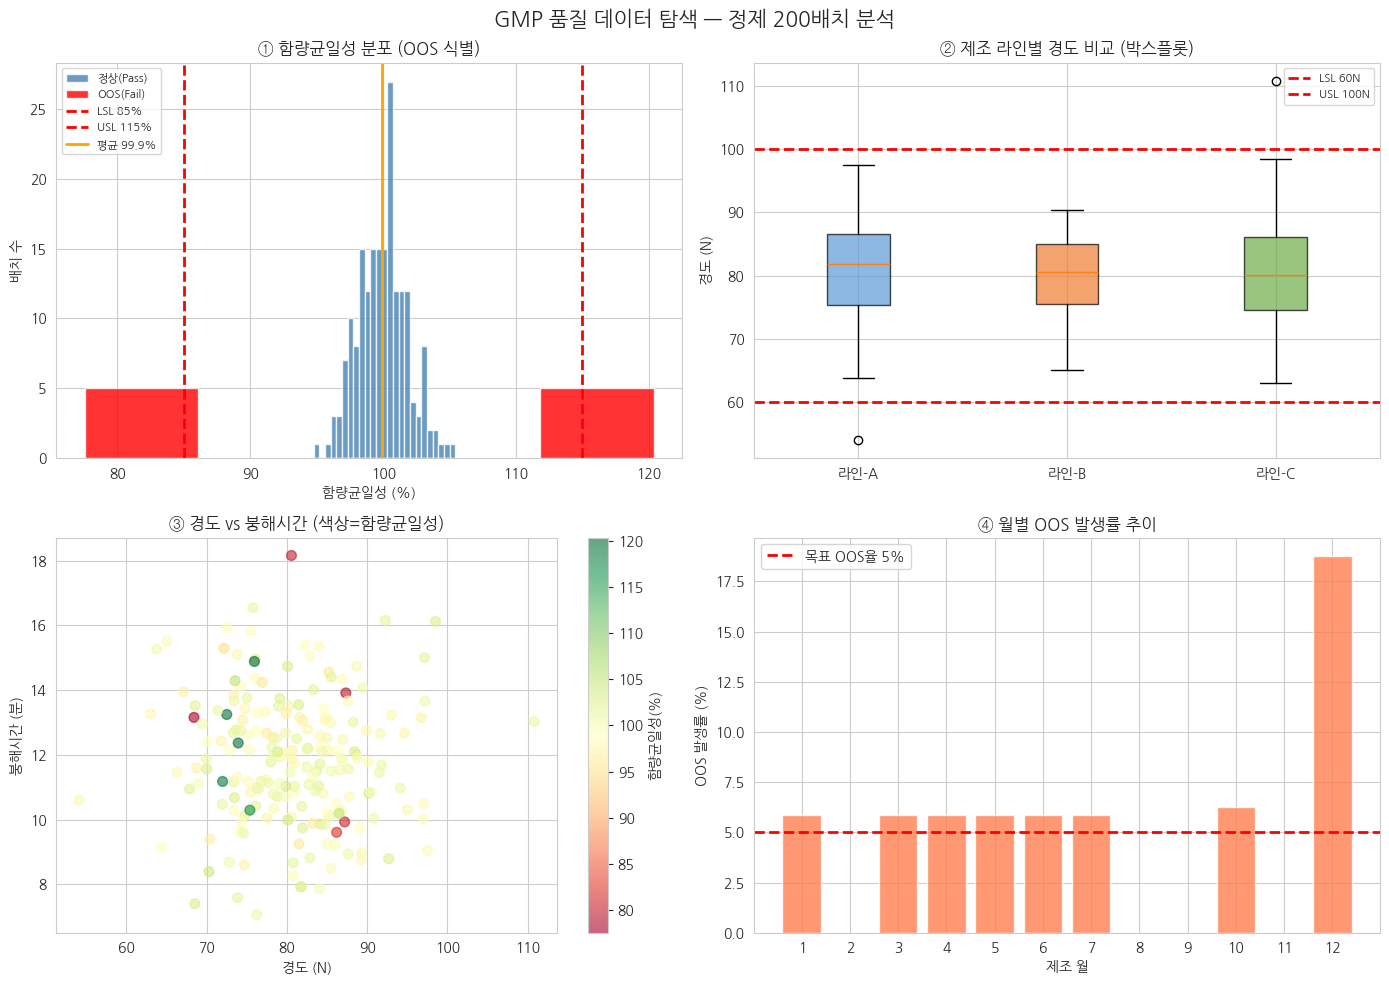


✅ 예제 1 완료!
📌 핵심 인사이트: 200배치 데이터를 단 몇 줄의 코드로 시각화하고 OOS 배치를 자동 식별했습니다.
   실제 업무에서는 LIMS 데이터를 pd.read_excel() 또는 pd.read_csv()로 불러와 동일하게 분석합니다.


In [ ]:
# ─────────────────────────────────────────────────────
# 1-3. 품질 데이터 4종 시각화
# ─────────────────────────────────────────────────────

# 2행 2열 총 4개의 그래프를 한 번에 그립니다
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('GMP 품질 데이터 탐색 — 정제 200배치 분석', fontsize=15, fontweight='bold')

# ── 그래프 ①: 함량균일성 히스토그램 (정상 vs OOS 비교) ──
ax1 = axes[0, 0]
ax1.hist(df[~df['OOS']]['assay_pct'], bins=25, color='steelblue',
         alpha=0.8, label='정상(Pass)', edgecolor='white')
ax1.hist(df[df['OOS']]['assay_pct'],  bins=5,  color='red',
         alpha=0.8, label='OOS(Fail)', edgecolor='white')
ax1.axvline(85,  color='red',    linestyle='--', linewidth=2, label='LSL 85%')
ax1.axvline(115, color='red',    linestyle='--', linewidth=2, label='USL 115%')
ax1.axvline(df['assay_pct'].mean(), color='orange', linewidth=2,
            label=f"평균 {df['assay_pct'].mean():.1f}%")
ax1.set_xlabel('함량균일성 (%)');  ax1.set_ylabel('배치 수')
ax1.set_title('① 함량균일성 분포 (OOS 식별)')
ax1.legend(fontsize=8)

# ── 그래프 ②: 제조 라인별 경도 박스플롯 ──
ax2 = axes[0, 1]
line_vals = [df[df['line']==l]['hardness_N'].values for l in ['라인-A', '라인-B', '라인-C']]
bp = ax2.boxplot(line_vals, labels=['라인-A', '라인-B', '라인-C'], patch_artist=True)
for patch, color in zip(bp['boxes'], ['#5b9bd5', '#ed7d31', '#70ad47']):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax2.axhline(60,  color='red', linestyle='--', linewidth=2, label='LSL 60N')
ax2.axhline(100, color='red', linestyle='--', linewidth=2, label='USL 100N')
ax2.set_ylabel('경도 (N)');  ax2.set_title('② 제조 라인별 경도 비교 (박스플롯)')
ax2.legend(fontsize=8)

# ── 그래프 ③: 경도 vs 붕해시간 산점도 (함량균일성 색상) ──
ax3 = axes[1, 0]
sc = ax3.scatter(df['hardness_N'], df['disint_min'],
                 c=df['assay_pct'], cmap='RdYlGn', alpha=0.6, s=50)
plt.colorbar(sc, ax=ax3, label='함량균일성(%)')
ax3.set_xlabel('경도 (N)');  ax3.set_ylabel('붕해시간 (분)')
ax3.set_title('③ 경도 vs 붕해시간 (색상=함량균일성)')

# ── 그래프 ④: 월별 OOS 발생률 막대그래프 ──
ax4 = axes[1, 1]
monthly = df.groupby('month')['OOS'].agg(['sum', 'count'])
monthly['rate'] = monthly['sum'] / monthly['count'] * 100
ax4.bar(monthly.index, monthly['rate'], color='coral', alpha=0.8, edgecolor='white')
ax4.axhline(5, color='red', linestyle='--', linewidth=2, label='목표 OOS율 5%')
ax4.set_xlabel('제조 월');  ax4.set_ylabel('OOS 발생률 (%)')
ax4.set_title('④ 월별 OOS 발생률 추이')
ax4.set_xticks(range(1, 13));  ax4.legend()

plt.tight_layout()
plt.savefig('예제1_품질데이터탐색.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ 예제 1 완료!")
print("📌 핵심 인사이트: 200배치 데이터를 단 몇 줄의 코드로 시각화하고 OOS 배치를 자동 식별했습니다.")
print("   실제 업무에서는 LIMS 데이터를 pd.read_excel() 또는 pd.read_csv()로 불러와 동일하게 분석합니다.")


---
## ✅ 예제 1 핵심 요약

| 항목 | 내용 |
|------|------|
| **GMP 적용** | ICH Q8 QbD — CPP/CQA 관계 데이터 기반 정량화 |
| **AI 기법** | EDA · 상관분석 · 다변량 시각화 |
| **핵심 성과** | 공정 파라미터 중 품질에 가장 영향 큰 CPP 상위 순위 파악 |
| **다음 단계** | 파악된 CPP를 예제 2(SPC)로 실시간 모니터링 → 예제 3(OOS)으로 예측 모델화 |

> 💡 **기억할 한 줄**: "AI 프로젝트 실패의 80%는 데이터 이해 부족에서 온다." — 예제 1이 가장 중요한 이유